In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Specify the directory containing your script
leaflet_repo = '/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/'

# Append this directory to sys.path
sys.path.append(leaflet_repo)
import Leaflet_load_cluster_data_03 as llc 

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


### Read in human muscle data 

In [5]:
leaflet_repo

'/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/'

In [6]:
input_files_folder = '/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle_Yes/'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)
simple_data_human = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

Reading in data from folder ...
/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle_Yes/
Finished reading in data from folder ...
['mesenchymal stem cell' 'macrophage' 't cell'
 'cd8-positive, alpha-beta t cell' 'tendon cell'
 'endothelial cell of lymphatic vessel' 'capillary endothelial cell'
 'endothelial cell of artery' 'fast muscle cell'
 'skeletal muscle satellite stem cell' 'slow muscle cell'
 'endothelial cell of vascular tree' 'mature nk t cell' 'pericyte cell'
 'mesothelial cell' 'cd4-positive, alpha-beta t cell' 'smooth muscle cell'
 'erythrocyte' 'mast cell']
5009
239882
The maximum junction count was initially:  825686
1359
The maximum junction count is now:  5000
                                       cell_id  Cluster  Cluster_Counts  \
0  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      146             191   
1  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      146             191   
2  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      

/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/Leaflet_load_cluster_data_03.py:45: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


### Read in mouse muscle data

In [7]:
input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)
simple_data_mouse = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/
Finished reading in data from folder ...
['Limb_Muscle_skeletal_muscle_satellite_cell' 'Limb_Muscle_macrophage'
 'Limb_Muscle_endothelial_cell' 'Limb_Muscle_mesenchymal_stem_cell'
 'Limb_Muscle_B_cell' 'Limb_Muscle_T_cell']
1090
158383
The maximum junction count was initially:  441914
326
The maximum junction count is now:  4964
                                             cell_id  Cluster  Cluster_Counts  \
0  A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...      141               5   
1  A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...      141               5   
2  A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...      142              13   
3  A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...      143              23   
4  A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...      144              14   

             junction_id  gene_id  junc_count  \
0  1_1712540

### Let's get some basic summaries of events observed in each specie muscle tissue 

Number of singletons in human data:  87808
Number of non-singletons in human data:  27248
        Cluster  counts
0             1       1
1             2       3
2             3       1
3             4       2
4             5       1
...         ...     ...
115051   116411       1
115052   116412       4
115053   116413       2
115054   116414       2
115055   116415       1

[115056 rows x 2 columns]


<Axes: xlabel='counts', ylabel='Count'>

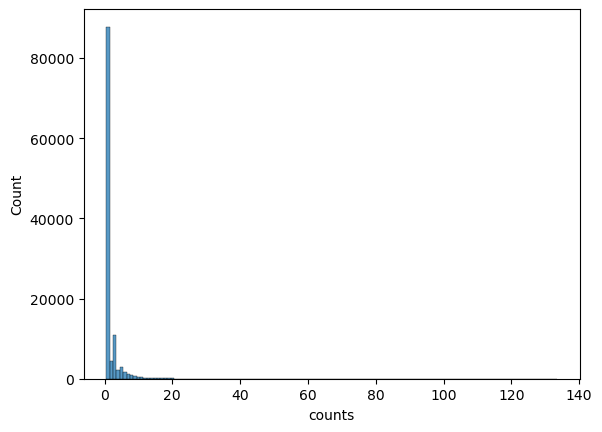

In [8]:
# calculate the number of singletons in the data (number of junctions in cluster == 1)
clusts_juncs = simple_data_human[["Cluster", "junction_id"]].drop_duplicates()
clusts_juncs = clusts_juncs.groupby("Cluster").size().reset_index(name='counts')
singletons = clusts_juncs[clusts_juncs['counts'] == 1]
human_singletons = singletons.copy()
not_singletons = clusts_juncs[clusts_juncs['counts'] != 1]
print("Number of singletons in human data: ", singletons.shape[0])
print("Number of non-singletons in human data: ", not_singletons.shape[0])
print(clusts_juncs) 

# make histogram of cluster sizes (number of junctions in intron cluster)
sns.histplot(clusts_juncs, x="counts", discrete=True, bins=100)

In [9]:
# calculate the number of singletons in the data (number of junctions in cluster == 1)
clusts_juncs = simple_data_mouse[["Cluster", "junction_id"]].drop_duplicates()
clusts_juncs = clusts_juncs.groupby("Cluster").size().reset_index(name='counts')
singletons = clusts_juncs[clusts_juncs['counts'] == 1]
mouse_singletons = singletons.copy()
print("Number of singletons in mouse data: ", singletons.shape[0])
print("Number of non-singletons in mouse data: ", clusts_juncs.shape[0] - singletons.shape[0])

Number of singletons in mouse data:  105418
Number of non-singletons in mouse data:  12106


### Find orthologs genes between human and mouse using pyensembl

In [10]:
simple_data_mouse

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,141,Limb_Muscle_skeletal_muscle_satellite_cell,0,0.2,1.0,5,1_171254063_171256147,Adamts4
1,0,141,Limb_Muscle_skeletal_muscle_satellite_cell,1,0.8,4.0,5,1_171256434_171256527,Adamts4
2,0,142,Limb_Muscle_skeletal_muscle_satellite_cell,2,1.0,13.0,13,1_171256714_171256954,Adamts4
3,0,143,Limb_Muscle_skeletal_muscle_satellite_cell,3,1.0,23.0,23,1_171257130_171257718,Adamts4
4,0,144,Limb_Muscle_skeletal_muscle_satellite_cell,4,1.0,14.0,14,1_171257894_171258751,Adamts4
...,...,...,...,...,...,...,...,...,...
15016417,1089,62476,Limb_Muscle_B_cell,156079,0.0,0.0,7,9_88715749_88731299,Gm2382
15016418,1089,46597,Limb_Muscle_B_cell,156119,0.0,0.0,69,7_141402069_141402743,Taldo1
15016419,1089,77669,Limb_Muscle_B_cell,156127,0.0,0.0,48,11_6508294_6510147,Myo1g
15016420,1089,57078,Limb_Muscle_B_cell,156138,0.0,0.0,89,8_22578100_22580339,Vdac3


In [11]:
import pyensembl
from pyensembl import EnsemblRelease

In [12]:
import requests

In [13]:
# Load Ensembl releases for human and mouse
ensembl_human = EnsemblRelease(93, species='homo_sapiens')  # Double check actual release used in the gtf file
ensembl_mouse = EnsemblRelease(93, species='mus_musculus')

In [14]:
#gene = ensembl_mouse.gene_by_id(gene_id='ENSMUSG00000006403')
#gene = ensembl_human.gene_by_id(gene_id='ENSG00000139618')

In [15]:
# orthologues genes file
import pandas as pd 
orthos = "/gpfs/commons/home/kisaev/ensembl_TS_TM_mart_export.txt"
orthos = pd.read_csv(orthos, sep='\t')
orthos.head()

,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Mouse gene name,Mouse gene stable ID,"Mouse orthology confidence [0 low, 1 high]",Mouse homology type,Last common ancestor with Mouse
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,mt-Nd1,ENSMUSG00000064341,1,ortholog_one2one,Euarchontoglires
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,mt-Nd2,ENSMUSG00000064345,1,ortholog_one2one,Euarchontoglires
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,mt-Co1,ENSMUSG00000064351,1,ortholog_one2one,Euarchontoglires
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,mt-Co2,ENSMUSG00000064354,1,ortholog_one2one,Mammalia
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,mt-Atp8,ENSMUSG00000064356,0,ortholog_one2one,Euarchontoglires


In [16]:
# make a dataframe of human genes in simple_data_human
simple_data_human["gene_id_clean"] = simple_data_human.gene_id.str.split('.').str[0]
simple_data_human

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id,gene_id_clean
0,0,146,mesenchymal stem cell,0,0.371728,71.0,191,1_150156206_150156910,ENSG00000023902.14,ENSG00000023902
1,0,146,mesenchymal stem cell,1,0.298429,57.0,191,1_150157015_150157384,ENSG00000023902.14,ENSG00000023902
2,0,146,mesenchymal stem cell,2,0.329843,63.0,191,1_150157486_150158818,ENSG00000023902.14,ENSG00000023902
3,0,424,mesenchymal stem cell,3,1.000000,33.0,33,1_109592255_109592344,ENSG00000065135.12,ENSG00000065135
4,0,476,mesenchymal stem cell,4,1.000000,28.0,28,1_42697262_42700780,ENSG00000065978.19,ENSG00000065978
...,...,...,...,...,...,...,...,...,...,...
31326793,4997,21650,mast cell,219352,0.000000,0.0,137,3_101849917_101852737,ENSG00000144802.11,ENSG00000144802
31326794,4997,31900,mast cell,219353,0.000000,0.0,148,5_57176400_57231097,ENSG00000062194.16,ENSG00000062194
31326795,4997,39567,mast cell,219356,0.000000,0.0,8,6_30008701_30009037,ENSG00000290574.1,ENSG00000290574
31326796,4997,28675,mast cell,219399,0.000000,0.0,36,4_99028918_99061153,ENSG00000164024.12,ENSG00000164024


In [17]:
orthos["gene_id_clean"] = orthos["Gene stable ID"]
orthos_genes = orthos[["gene_id_clean", "Mouse gene name", "Mouse gene stable ID", "Mouse orthology confidence [0 low, 1 high]", "Mouse homology type", "Last common ancestor with Mouse"]].drop_duplicates()
# keep only confidence score of 1
orthos_genes = orthos_genes[orthos_genes["Mouse orthology confidence [0 low, 1 high]"]==1]

In [18]:
orthos_genes

,gene_id_clean,Mouse gene name,Mouse gene stable ID,"Mouse orthology confidence [0 low, 1 high]",Mouse homology type,Last common ancestor with Mouse
0,ENSG00000198888,mt-Nd1,ENSMUSG00000064341,1,ortholog_one2one,Euarchontoglires
1,ENSG00000198763,mt-Nd2,ENSMUSG00000064345,1,ortholog_one2one,Euarchontoglires
2,ENSG00000198804,mt-Co1,ENSMUSG00000064351,1,ortholog_one2one,Euarchontoglires
3,ENSG00000198712,mt-Co2,ENSMUSG00000064354,1,ortholog_one2one,Mammalia
5,ENSG00000198899,mt-Atp6,ENSMUSG00000064357,1,ortholog_one2one,Eutheria
...,...,...,...,...,...,...
179766,ENSG00000175087,Pdik1l,ENSMUSG00000050890,1,ortholog_one2one,Euarchontoglires
179770,ENSG00000197245,Fam110d,ENSMUSG00000050105,1,ortholog_one2one,Boreoeutheria
179771,ENSG00000282872,Gm30191,ENSMUSG00000108398,1,ortholog_one2one,Eutheria
179773,ENSG00000142684,Zfp593,ENSMUSG00000028840,1,ortholog_one2one,Euarchontoglires


In [19]:
orthos_genes["Mouse homology type"].value_counts()

ortholog_one2one      16085
ortholog_one2many       972
ortholog_many2many      556
Name: Mouse homology type, dtype: int64

In [20]:
simple_data_human

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id,gene_id_clean
0,0,146,mesenchymal stem cell,0,0.371728,71.0,191,1_150156206_150156910,ENSG00000023902.14,ENSG00000023902
1,0,146,mesenchymal stem cell,1,0.298429,57.0,191,1_150157015_150157384,ENSG00000023902.14,ENSG00000023902
2,0,146,mesenchymal stem cell,2,0.329843,63.0,191,1_150157486_150158818,ENSG00000023902.14,ENSG00000023902
3,0,424,mesenchymal stem cell,3,1.000000,33.0,33,1_109592255_109592344,ENSG00000065135.12,ENSG00000065135
4,0,476,mesenchymal stem cell,4,1.000000,28.0,28,1_42697262_42700780,ENSG00000065978.19,ENSG00000065978
...,...,...,...,...,...,...,...,...,...,...
31326793,4997,21650,mast cell,219352,0.000000,0.0,137,3_101849917_101852737,ENSG00000144802.11,ENSG00000144802
31326794,4997,31900,mast cell,219353,0.000000,0.0,148,5_57176400_57231097,ENSG00000062194.16,ENSG00000062194
31326795,4997,39567,mast cell,219356,0.000000,0.0,8,6_30008701_30009037,ENSG00000290574.1,ENSG00000290574
31326796,4997,28675,mast cell,219399,0.000000,0.0,36,4_99028918_99061153,ENSG00000164024.12,ENSG00000164024


In [21]:
human_genes_juncs = simple_data_human[["gene_id_clean", "junction_id"]].drop_duplicates()
human_genes_juncs

,gene_id_clean,junction_id
0,ENSG00000023902,1_150156206_150156910
1,ENSG00000023902,1_150157015_150157384
2,ENSG00000023902,1_150157486_150158818
3,ENSG00000065135,1_109592255_109592344
4,ENSG00000065978,1_42697262_42700780
...,...,...
14771969,ENSG00000155966,X_148843415_148885888
14771970,ENSG00000155966,X_148885985_148904220
14771971,ENSG00000155966,X_148904258_148953579
14771972,ENSG00000155966,X_148953739_148955602


In [22]:
# merge human simple data with orthos
human_orthos = human_genes_juncs.merge(orthos_genes, on="gene_id_clean")

In [23]:
human_orthos

,gene_id_clean,junction_id,Mouse gene name,Mouse gene stable ID,"Mouse orthology confidence [0 low, 1 high]",Mouse homology type,Last common ancestor with Mouse
0,ENSG00000023902,1_150156206_150156910,Plekho1,ENSMUSG00000015745,1,ortholog_one2one,Eutheria
1,ENSG00000023902,1_150157015_150157384,Plekho1,ENSMUSG00000015745,1,ortholog_one2one,Eutheria
2,ENSG00000023902,1_150157486_150158818,Plekho1,ENSMUSG00000015745,1,ortholog_one2one,Eutheria
3,ENSG00000023902,1_150150287_150150911,Plekho1,ENSMUSG00000015745,1,ortholog_one2one,Eutheria
4,ENSG00000023902,1_150151058_150156065,Plekho1,ENSMUSG00000015745,1,ortholog_one2one,Eutheria
...,...,...,...,...,...,...,...
181652,ENSG00000116176,16_1223594_1224601,Tpsg1,ENSMUSG00000033200,1,ortholog_one2one,Euarchontoglires
181653,ENSG00000180035,16_30395578_30395779,Zfp553,ENSMUSG00000045598,1,ortholog_one2one,Euarchontoglires
181654,ENSG00000180035,16_30395873_30397329,Zfp553,ENSMUSG00000045598,1,ortholog_one2one,Euarchontoglires
181655,ENSG00000126251,19_35371118_35371348,Ffar3,ENSMUSG00000019429,1,ortholog_one2many,Eutheria


In [24]:
print("The number of unique human genes with mouse orthologues: ", human_orthos.gene_id_clean.nunique())
print("The number of unique mouse genes: ", human_orthos["Mouse gene stable ID"].nunique())

The number of unique human genes with mouse orthologues:  13329
The number of unique mouse genes:  13404


In [25]:
# which human genes have more than one mouse orthologues?
genesonly = human_orthos[["gene_id_clean", "Mouse gene stable ID"]].drop_duplicates()
genesonly = genesonly.groupby("gene_id_clean").size().reset_index(name='counts')

In [26]:
genesonly[genesonly["counts"] > 1]

,gene_id_clean,counts
107,ENSG00000006059,3
312,ENSG00000016602,2
384,ENSG00000026297,2
1399,ENSG00000085563,2
1532,ENSG00000089127,2
...,...,...
13042,ENSG00000244122,3
13248,ENSG00000273841,2
13266,ENSG00000275791,2
13269,ENSG00000275896,5


In [27]:
orthos_genes[orthos_genes["gene_id_clean"] == "ENSG00000275791"]

,gene_id_clean,Mouse gene name,Mouse gene stable ID,"Mouse orthology confidence [0 low, 1 high]",Mouse homology type,Last common ancestor with Mouse
68503,ENSG00000275791,Trbv13-2,ENSMUSG00000076469,1,ortholog_many2many,Euarchontoglires
68505,ENSG00000275791,Trbv13-3,ENSMUSG00000076470,1,ortholog_many2many,Euarchontoglires


In [28]:
# how many of the orthos mouse genes appear in our data 
mouse_genes_juncs = simple_data_mouse[["gene_id", "junction_id"]].drop_duplicates()

In [29]:
mouse_genes_juncs = mouse_genes_juncs[mouse_genes_juncs["gene_id"].isin(human_orthos["Mouse gene name"])]

In [30]:
mouse_genes_juncs[mouse_genes_juncs["gene_id"] == "Adamts4"]

,gene_id,junction_id
0,Adamts4,1_171254063_171256147
1,Adamts4,1_171256434_171256527
2,Adamts4,1_171256714_171256954
3,Adamts4,1_171257130_171257718
4,Adamts4,1_171257894_171258751
16358,Adamts4,1_171251469_171252536
16359,Adamts4,1_171252860_171253086
16360,Adamts4,1_171253219_171253892
2084117,Adamts4,1_171251469_171253086
2714659,Adamts4,1_171253219_171256527


In [31]:
human_orthos[human_orthos["Mouse gene name"] == "Adamts4"]

,gene_id_clean,junction_id,Mouse gene name,Mouse gene stable ID,"Mouse orthology confidence [0 low, 1 high]",Mouse homology type,Last common ancestor with Mouse
88453,ENSG00000158859,1_161191564_161192064,Adamts4,ENSMUSG00000006403,1,ortholog_one2one,Euarchontoglires
88454,ENSG00000158859,1_161192240_161193639,Adamts4,ENSMUSG00000006403,1,ortholog_one2one,Euarchontoglires
88455,ENSG00000158859,1_161193826_161193934,Adamts4,ENSMUSG00000006403,1,ortholog_one2one,Euarchontoglires
88456,ENSG00000158859,1_161194221_161195464,Adamts4,ENSMUSG00000006403,1,ortholog_one2one,Euarchontoglires
88457,ENSG00000158859,1_161195635_161196170,Adamts4,ENSMUSG00000006403,1,ortholog_one2one,Euarchontoglires
88458,ENSG00000158859,1_161196880_161197994,Adamts4,ENSMUSG00000006403,1,ortholog_one2one,Euarchontoglires
88459,ENSG00000158859,1_161196303_161196556,Adamts4,ENSMUSG00000006403,1,ortholog_one2one,Euarchontoglires
88460,ENSG00000158859,1_161192240_161193212,Adamts4,ENSMUSG00000006403,1,ortholog_one2one,Euarchontoglires
88461,ENSG00000158859,1_161193388_161193639,Adamts4,ENSMUSG00000006403,1,ortholog_one2one,Euarchontoglires


the median number of junctions detected in a single cell (human):  5143.5


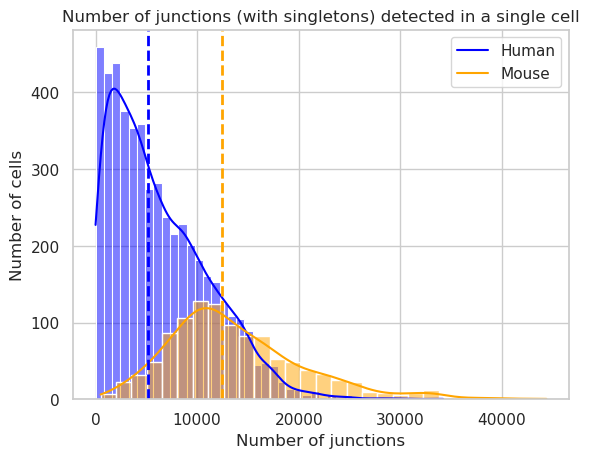

In [32]:
# How many junctions detected in a single cell 
num_juncs_cell = simple_data_human.groupby("cell_id_index").size().reset_index(name='num_juncs')
num_juncs_cell_mouse = simple_data_mouse.groupby("cell_id_index").size().reset_index(name='num_juncs')
print("the median number of junctions detected in a single cell (human): ", num_juncs_cell["num_juncs"].median())
print("the median number of junctions detected in a single cell (human): ", num_juncs_cell_mouse["num_juncs"].median())

# make a histogram of the number of junctions detected in a single cell
sns.set_theme(style="whitegrid")
sns.histplot(num_juncs_cell, x="num_juncs", kde=True, color="blue")
# make curve for mouse also but make it a different color
sns.histplot(num_juncs_cell_mouse, x="num_juncs", kde=True, color="orange")
plt.title("Number of junctions (with singletons) detected in a single cell")
plt.xlabel("Number of junctions")
plt.ylabel("Number of cells")
# add legend
plt.legend(["Human", "Mouse"])
# add median lines 
plt.axvline(num_juncs_cell["num_juncs"].median(), color='blue', linestyle='dashed', linewidth=2)
plt.axvline(num_juncs_cell_mouse["num_juncs"].median(), color='orange', linestyle='dashed', linewidth=2)

the median number of junctions detected in a single cell (human):  4349.0
the median number of junctions detected in a single cell (mouse):  7439.0


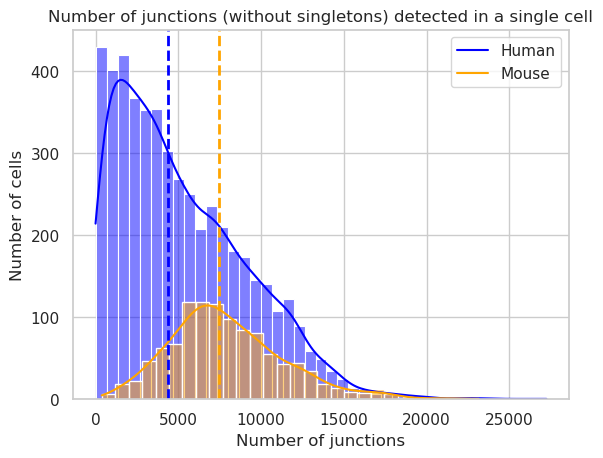

In [33]:
# remove human singletons from simple_data_human via Cluster column and re-calculate the number of junctions detected in a single cell
simple_data_human = simple_data_human[~simple_data_human["Cluster"].isin(human_singletons["Cluster"])]
num_juncs_cell = simple_data_human.groupby("cell_id_index").size().reset_index(name='num_juncs')
print("the median number of junctions detected in a single cell (human): ", num_juncs_cell["num_juncs"].median())

# remove mouse singletons from simple_data_mouse via Cluster column and re-calculate the number of junctions detected in a single cell
simple_data_mouse = simple_data_mouse[~simple_data_mouse["Cluster"].isin(mouse_singletons["Cluster"])]
num_juncs_cell_mouse = simple_data_mouse.groupby("cell_id_index").size().reset_index(name='num_juncs')
print("the median number of junctions detected in a single cell (mouse): ", num_juncs_cell_mouse["num_juncs"].median())

sns.histplot(num_juncs_cell, x="num_juncs", kde=True, color="blue")
sns.histplot(num_juncs_cell_mouse, x="num_juncs", kde=True, color="orange")
plt.title("Number of junctions (without singletons) detected in a single cell")
plt.xlabel("Number of junctions")
plt.ylabel("Number of cells")
plt.legend(["Human", "Mouse"])
plt.axvline(num_juncs_cell["num_juncs"].median(), color='blue', linestyle='dashed', linewidth=2)
plt.axvline(num_juncs_cell_mouse["num_juncs"].median(), color='orange', linestyle='dashed', linewidth=2)

In [38]:
# let's save the human gene to mouse gene conversion
human_orthos

# write the steps we used to obtain the human orthos file
# 1. Load the orthos file which was downloaded from Ensembl 
# 2. Filtered the orthos file to keep only the genes with confidence score of 1
# 3. Merge the human gene id with the simple_data_human file to obtain the mouse gene id for all observed human junctions in muscle

# So the genes in human_orthos are those that have been observed in our data and have a mouse orthologues with confidence score of 1 
# we can check if these mouse genes are present in the mouse data

human_orthos.to_csv("/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/human_orthos_observed_muscle.csv", index=False, sep='\t', header=True)

In [36]:
# check wd
!pwd

/gpfs/commons/home/kisaev/Leaflet-analysis/TM_vs_TS


In [41]:
# let's plot the number of counts across junctions for human and mouse data
# for every junction in simple_data_human, get sum of junc_count and keep only junction_id and to0tal counts 
human_junc_counts = simple_data_human.groupby("junction_id_index")["junc_count"].sum().reset_index(name='total_counts')
mouse_junc_counts = simple_data_mouse.groupby("junction_id_index")["junc_count"].sum().reset_index(name='total_counts')

In [52]:
human_junc_counts["log_total_counts"] = np.log(human_junc_counts.total_counts)

,junction_id_index,total_counts,log_total_counts
0,0,7115.0,8.869961
1,1,8785.0,9.080801
2,2,11987.0,9.391578
3,4,132742.0,11.796163
4,7,24899.0,10.122583
...,...,...,...
131664,219464,47.0,3.850148
131665,219465,35.0,3.555348
131666,219466,33.0,3.496508
131667,219467,82.0,4.406719


In [53]:
mouse_junc_counts["log_total_counts"] = np.log(mouse_junc_counts.total_counts)

,junction_id_index,total_counts,log_total_counts
0,0,7916.0,8.976641
1,1,7817.0,8.964056
2,5,4226.0,8.349011
3,6,27601.0,10.225607
4,8,32042.0,10.374803
...,...,...,...
50730,156147,6.0,1.791759
50731,156148,6.0,1.791759
50732,156149,8.0,2.079442
50733,156150,13.0,2.564949


The median log junction read counts (human):  6.3561076606958915
The median log junction read counts (mouse):  5.986452005284438


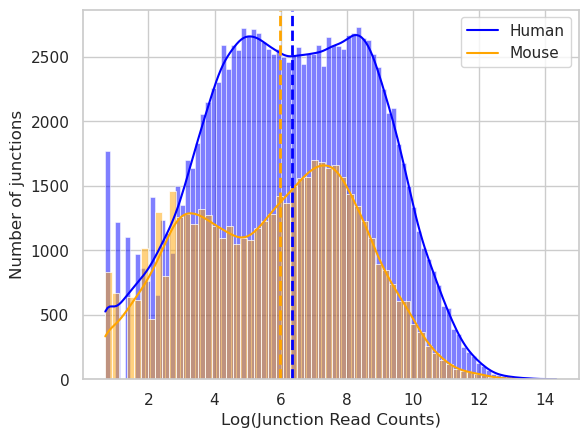

In [67]:
sns.histplot(human_junc_counts, x="log_total_counts", kde=True, color="blue")
sns.histplot(mouse_junc_counts, x="log_total_counts", kde=True, color="orange")
# add legend 
plt.legend(["Human", "Mouse"])
# change xaxis label to say Log(Junction Read Counts)
plt.xlabel("Log(Junction Read Counts)")
# y label should say number of junctions 
plt.ylabel("Number of junctions")
# add median lines
plt.axvline(human_junc_counts["log_total_counts"].median(), color='blue', linestyle='dashed', linewidth=2)
plt.axvline(mouse_junc_counts["log_total_counts"].median(), color='orange', linestyle='dashed', linewidth=2)
print("The median log junction read counts (human): ", human_junc_counts["log_total_counts"].median())
print("The median log junction read counts (mouse): ", mouse_junc_counts["log_total_counts"].median())

In [68]:
np.exp(5.98645), np.exp(6.356)

(397.9992018975938, 575.9379907772045)

In [56]:
human_cluster_counts = simple_data_human.groupby("Cluster")["junc_count"].sum().reset_index(name='total_counts')
mouse_cluster_counts = simple_data_mouse.groupby("Cluster")["junc_count"].sum().reset_index(name='total_counts')

# convert total_counts to log scale
human_cluster_counts["log_total_counts"] = np.log(human_cluster_counts.total_counts)
mouse_cluster_counts["log_total_counts"] = np.log(mouse_cluster_counts.total_counts)

human_cluster_counts.head()

,Cluster,total_counts,log_total_counts
0,2,1894.0,7.546446
1,4,1195.0,7.085901
2,16,2651.0,7.882692
3,17,2827.0,7.946971
4,21,102765.0,11.540200


The median log total counts for human clusters:  8.802221735092592
The median log total counts for mouse clusters:  8.001689978099135


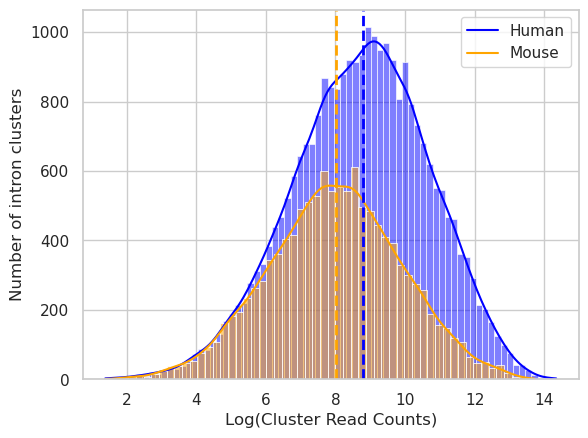

In [65]:
sns.histplot(human_cluster_counts, x="log_total_counts", kde=True, color="blue")
sns.histplot(mouse_cluster_counts, x="log_total_counts", kde=True, color="orange")
# add legend
plt.legend(["Human", "Mouse"])
# change xaxis label to say Log(Cluster Read Counts)
plt.xlabel("Log(Cluster Read Counts)")
# y label should say number of clusters
plt.ylabel("Number of intron clusters")
# add median lines
plt.axvline(human_cluster_counts["log_total_counts"].median(), color='blue', linestyle='dashed', linewidth=2)
plt.axvline(mouse_cluster_counts["log_total_counts"].median(), color='orange', linestyle='dashed', linewidth=2)

print("The median log total counts for human clusters: ", human_cluster_counts["log_total_counts"].median())
print("The median log total counts for mouse clusters: ", mouse_cluster_counts["log_total_counts"].median())

In [66]:
np.exp(8.001689978099135), np.exp(8.802221735092592)

(2985.9999999999973, 6648.999924800724)